In [1]:
# Importinf Libraries
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import IsolationForest

In [2]:
# Importing Dataset
df=pd.read_csv('Midterm_53_group.csv')
print(df.shape)


(394136, 7)


In [3]:
print(df.info())
print(df.isnull().sum())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 394136 entries, 0 to 394135
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Time         394136 non-null  float64
 1   Source       394136 non-null  object 
 2   No.          394136 non-null  int64  
 3   Destination  394136 non-null  object 
 4   Protocol     394136 non-null  object 
 5   Length       394136 non-null  int64  
 6   Info         394136 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 21.0+ MB
None
Time           0
Source         0
No.            0
Destination    0
Protocol       0
Length         0
Info           0
dtype: int64


In [4]:
data=df.copy()


In [5]:
data.head()
# data.describe()

,Time,Source,No.,Destination,Protocol,Length,Info
0,0.000000,192.167.8.166,1,192.167.255.255,NBNS,92,Name query NB WPAD<00>
1,0.784682,192.167.8.166,2,192.167.255.255,NBNS,92,Name query NB WPAD<00>
2,1.169060,VMware_8a:5c:e6,3,Broadcast,ARP,60,Who has 192.167.7.175? Tell 192.167.0.1
3,2.167949,VMware_8a:5c:e6,4,Broadcast,ARP,60,Who has 192.167.7.175? Tell 192.167.0.1
4,3.170095,VMware_8a:5c:e6,5,Broadcast,ARP,60,Who has 192.167.7.175? Tell 192.167.0.1


In [6]:
# Encoding
Label_encoder=LabelEncoder()

data['protocol_encoded']=Label_encoder.fit_transform(data['Protocol'])

data['Source_encoded']=Label_encoder.fit_transform(data['Source'])

data['Destination_encoded']=Label_encoder.fit_transform(data['Destination'])



In [7]:
# feature Selection
features=data[[
        "Time",
        "Length",
        "protocol_encoded",
        "Source_encoded",
        "Destination_encoded"
    ]]



In [8]:
# Feature Scaling
scaler=StandardScaler()

X_scaled=scaler.fit_transform(features)



In [9]:
# ISOLATION FOREST MODEL
iso_forest=IsolationForest(
    contamination=0.01,
    random_state=42
)

iso_forest.fit(X_scaled)


,n_estimators,100
,max_samples,'auto'
,contamination,0.01
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [10]:
# Predictiong Anomalies
data['Anomaly']=iso_forest.predict(X_scaled)

data['Anomaly']=data['Anomaly'].map({1:0,-1:1})

data.head()

,Time,Source,No.,Destination,Protocol,Length,Info,protocol_encoded,Source_encoded,Destination_encoded,Anomaly
0,0.000000,192.167.8.166,1,192.167.255.255,NBNS,92,Name query NB WPAD<00>,7,183,152,0
1,0.784682,192.167.8.166,2,192.167.255.255,NBNS,92,Name query NB WPAD<00>,7,183,152,0
2,1.169060,VMware_8a:5c:e6,3,Broadcast,ARP,60,Who has 192.167.7.175? Tell 192.167.0.1,0,347,303,1
3,2.167949,VMware_8a:5c:e6,4,Broadcast,ARP,60,Who has 192.167.7.175? Tell 192.167.0.1,0,347,303,1
4,3.170095,VMware_8a:5c:e6,5,Broadcast,ARP,60,Who has 192.167.7.175? Tell 192.167.0.1,0,347,303,1


In [11]:
print(data['Anomaly'].value_counts())

Anomaly
0    390206
1      3930
Name: count, dtype: int64


In [12]:
# Anomaly Score
data["Anomaly_Score"] = iso_forest.decision_function(
    X_scaled
)

In [13]:
# Top Anomalies
top_anomalies = data.sort_values(
    by="Anomaly_Score"
)

print(
    top_anomalies[
        [
            "Time",
            "Source",
            "Destination",
            "Protocol",
            "Length",
            "Anomaly_Score"
        ]
    ].head(2)
)

         Time           Source Destination Protocol  Length  Anomaly_Score
57  41.084310  VMware_8a:a0:c6   Broadcast      ARP      60      -0.109947
46  39.084263  VMware_8a:a0:c6   Broadcast      ARP      60      -0.109947


### VISUALIZATION


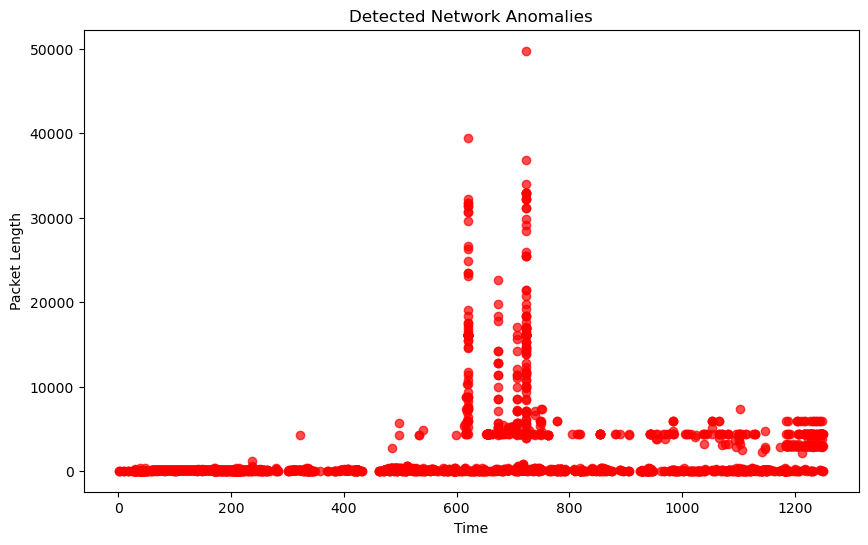

In [14]:
anomalies = data[data["Anomaly"] == 1]

plt.figure(figsize=(10,6))

plt.scatter(
    anomalies["Time"],
    anomalies["Length"],
    color="red",
    alpha=0.7
)

plt.title("Detected Network Anomalies")
plt.xlabel("Time")
plt.ylabel("Packet Length")

plt.show()

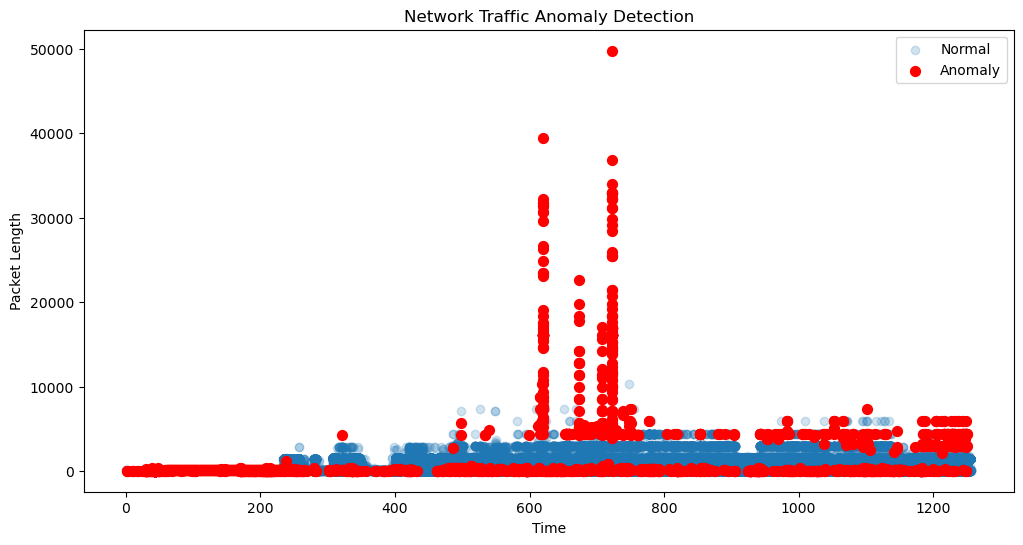

In [15]:
normal = data[data["Anomaly"] == 0]
anomaly = data[data["Anomaly"] == 1]

plt.figure(figsize=(12,6))

plt.scatter(
    normal["Time"],
    normal["Length"],
    alpha=0.2,
    label="Normal"
)

plt.scatter(
    anomaly["Time"],
    anomaly["Length"],
    color="red",
    s=50,
    label="Anomaly"
)

plt.legend()

plt.xlabel("Time")
plt.ylabel("Packet Length")
plt.title("Network Traffic Anomaly Detection")

plt.show()

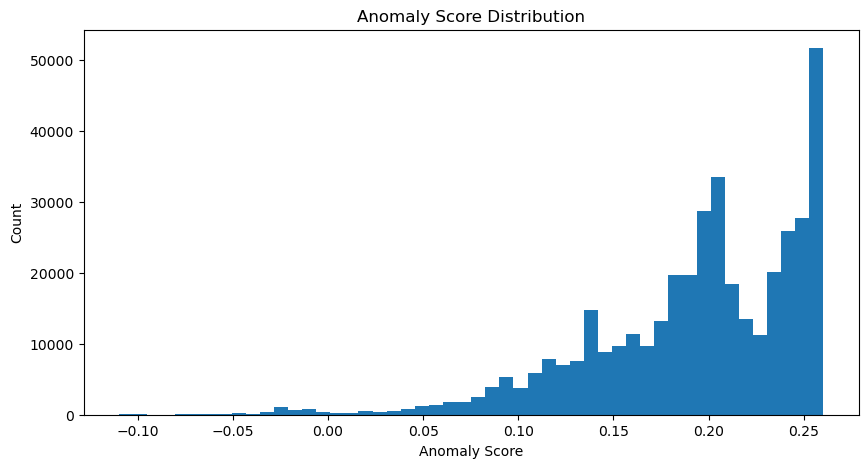

In [16]:
plt.figure(figsize=(10,5))

plt.hist(
    data["Anomaly_Score"],
    bins=50
)

plt.title("Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Count")

plt.show()

In [17]:
# Saving Results
data.to_csv(
    "network_anomalies.csv",
    index=False
)

print("Results Saved Successfully")

Results Saved Successfully
